# Eritrea: June to August 2026 compared with past seasons

- **Rainfall**: CHIRPS dekadal totals by admin 1 (WFP subnational table), 1981 to 2026.
- **NDVI**: MODIS dekadal NDVI and % of average by admin 1 (WFP subnational table), 2003 to 2026.
- **CDI**: ICPAC East Africa Drought Watch monthly Combined Drought Indicator, 2020 to 2026, from HDX.

Season window: the 9 dekads from 1 June to 31 August (JJA). All JJA 2026 rainfall
dekads are `final`; only the September 2026 dekads are `prelim`.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import ocha_stratus as stratus
import pandas as pd

from eri_drought import cdi, data
from eri_drought.constants import PROJECT_PREFIX

CURRENT = 2026
JJA = [6, 7, 8]
# One colour system for every chart:
#   blue = 2026, greys = past years / ranges / averages,
#   one orange ramp (light -> dark) = dryness (rainfall deficit, CDI Watch -> Alert).
C_CURRENT = "#2a78d6"
C_PAST = "#c3c2b7"
C_AVG = "#52514e"
DRY = ["#ef9868", "#d9591f", "#8f2f0b"]
NEUTRAL = "#f0efec"
INK_2 = "#52514e"
GRID = "#e1e0d9"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "axes.labelcolor": INK_2,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "font.size": 9,
    }
)

adm1 = data.load_adm1()
rain = data.load_rainfall_adm1()
ndvi = data.load_ndvi_adm1()
ORDER = ["ER1", "ER2", "ER3", "ER4", "ER5", "ER6"]


def month_ticks(ax, dekads: pd.Index) -> None:
    """Tick the first dekad of each month, labelled with the month name."""
    pos = [i for i, d in enumerate(dekads) if d.endswith("-01")]
    ax.set_xticks(pos, [pd.Timestamp(f"2000-{dekads[i]}").strftime("%b") for i in pos])
LABEL = {p: f"{data.ADM1_NAMES[p]} ({p})" for p in ORDER}

## Admin 1 areas

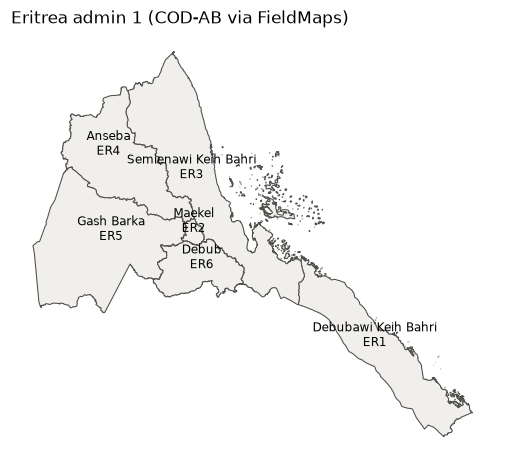

In [2]:
fig, ax = plt.subplots(figsize=(6, 5))
adm1.plot(ax=ax, color=NEUTRAL, edgecolor=INK_2, linewidth=0.7)
for _, r in adm1.iterrows():
    pt = r.geometry.representative_point()
    ax.annotate(f"{r.adm1_name}\n{r.PCODE}", (pt.x, pt.y), ha="center", fontsize=8)
ax.set_axis_off()
ax.set_title("Eritrea admin 1 (COD-AB via FieldMaps)", loc="left")
plt.show()

## 1. Rainfall: June to August total by admin 1

June to August values are WFP's 3-month rolling columns on the 21 August dekad:
`r3h` (mm), `r3h_avg` (1989-2018 average, mm) and `r3q` (% of average).

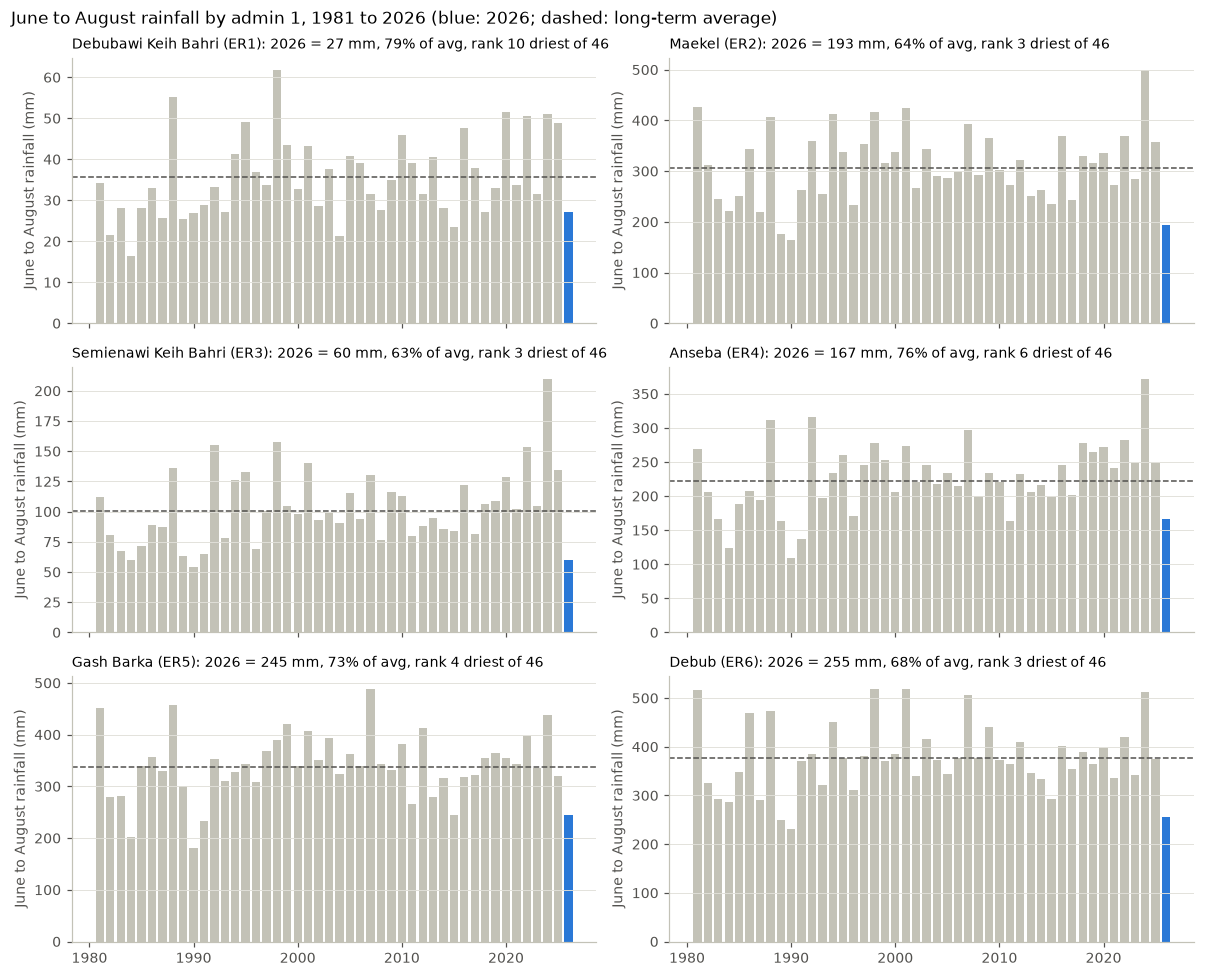

In [3]:
# June to August = the 3-month rolling values on the 21 August dekad (1 Jun to 31 Aug):
# r3h / r3h_avg for amounts, WFP's r3q for % of average.
jja_rain = (
    rain[(rain.month == 8) & (rain.date.dt.day == 21)]
    .rename(columns={"r3h": "rain_mm", "r3h_avg": "avg_mm", "r3q": "pct_avg"})
    [["PCODE", "year", "rain_mm", "avg_mm", "pct_avg"]]
    .reset_index(drop=True)
)
jja_rain["rank_driest"] = jja_rain.groupby("PCODE").pct_avg.rank(method="min").astype(int)
n_years = jja_rain.year.nunique()

fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)
for ax, p in zip(axes.flat, ORDER):
    d = jja_rain[jja_rain.PCODE == p]
    colors = np.where(d.year == CURRENT, C_CURRENT, C_PAST)
    ax.bar(d.year, d.rain_mm, color=colors, width=0.8)
    ax.axhline(d.avg_mm.iloc[0], color=C_AVG, lw=1, ls="--")
    cur = d[d.year == CURRENT].iloc[0]
    ax.set_title(
        f"{LABEL[p]}: {CURRENT} = {cur.rain_mm:.0f} mm, "
        f"{cur.pct_avg:.0f}% of avg, rank {cur.rank_driest} driest of {n_years}",
        loc="left",
        fontsize=9,
    )
    ax.set_ylabel("June to August rainfall (mm)")
fig.suptitle(
    f"June to August rainfall by admin 1, 1981 to {CURRENT} "
    f"(blue: {CURRENT}; dashed: long-term average)",
    x=0.01,
    ha="left",
)
fig.tight_layout()
plt.show()

JJA rainfall as % of the long-term average, every year and admin 1.

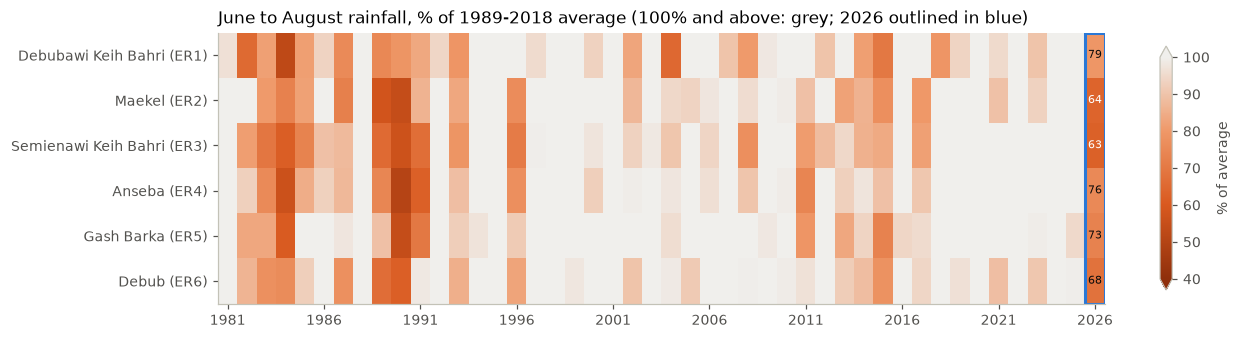

In [4]:
pct = jja_rain.pivot(index="PCODE", columns="year", values="pct_avg").loc[ORDER]
fig, ax = plt.subplots(figsize=(13, 3.2))
dry_cmap = LinearSegmentedColormap.from_list("dry", [DRY[2], DRY[1], DRY[0], NEUTRAL])
im = ax.imshow(pct.values, cmap=dry_cmap, vmin=40, vmax=100, aspect="auto")
ax.set_yticks(range(len(ORDER)), [LABEL[p] for p in ORDER])
ax.set_xticks(range(0, n_years, 5), pct.columns[::5])
ax.grid(False)
for j in np.where(pct.columns == CURRENT)[0]:
    ax.add_patch(plt.Rectangle((j - 0.5, -0.5), 1, len(ORDER), fill=False, ec=C_CURRENT, lw=2))
    for i, v in enumerate(pct.iloc[:, j]):
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                color="white" if v < 65 else "#0b0b0b")
fig.colorbar(im, ax=ax, label="% of average", shrink=0.9, extend="both")
ax.set_title(
    "June to August rainfall, % of 1989-2018 average (100% and above: grey; 2026 outlined in blue)",
    loc="left",
)
plt.show()

In [5]:
summary_rain = jja_rain[jja_rain.year == CURRENT].set_index("PCODE").loc[ORDER]
driest_years = (
    jja_rain.sort_values("pct_avg")
    .groupby("PCODE")
    .head(5)
    .groupby("PCODE")
    .year.apply(lambda s: ", ".join(map(str, s)))
)
summary_rain = summary_rain.assign(
    adm1=lambda d: d.index.map(data.ADM1_NAMES), five_driest_years=driest_years
)[["adm1", "rain_mm", "avg_mm", "pct_avg", "rank_driest", "five_driest_years"]].round(0)
summary_rain

,adm1,rain_mm,avg_mm,pct_avg,rank_driest,five_driest_years
PCODE,,,,,,
ER1,Debubawi Keih Bahri,27.0,36.0,79.0,10,"1984, 2004, 1982, 2015, 1989"
ER2,Maekel,193.0,306.0,64.0,3,"1990, 1989, 2026, 1987, 1984"
ER3,Semienawi Keih Bahri,60.0,100.0,63.0,3,"1990, 1984, 2026, 1989, 1991"
ER4,Anseba,167.0,222.0,76.0,6,"1990, 1984, 1991, 2011, 1989"
ER5,Gash Barka,245.0,337.0,73.0,4,"1990, 1984, 1991, 2026, 2015"
ER6,Debub,255.0,377.0,68.0,3,"1990, 1989, 2026, 1984, 1987"


Dekad by dekad in 2026 against the spread of 1981 to 2025.

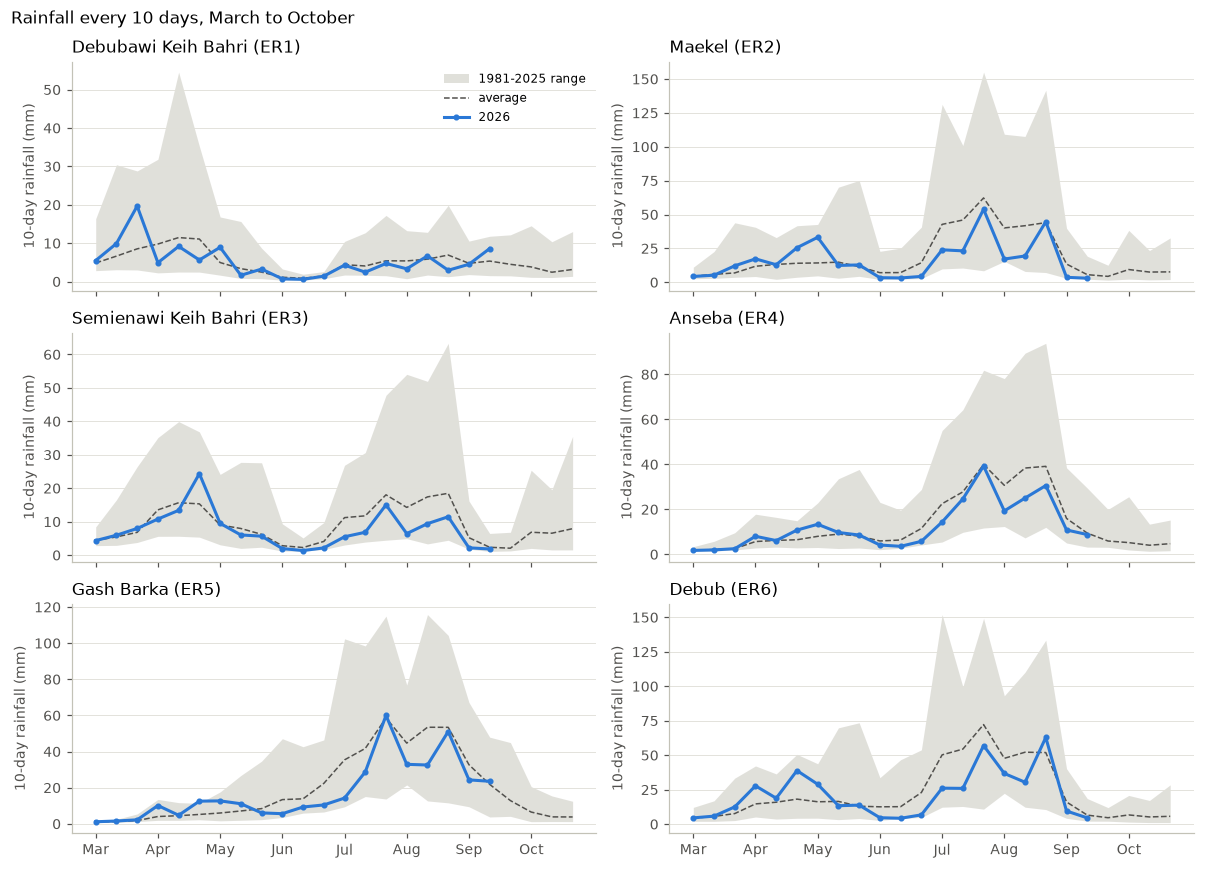

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for ax, p in zip(axes.flat, ORDER):
    d = rain[(rain.PCODE == p) & rain.month.between(3, 10)].copy()
    d["dekad"] = d.date.dt.strftime("%m-%d")
    past = d[d.year < CURRENT].groupby("dekad").rfh.agg(["min", "max"])
    avg = d.groupby("dekad").rfh_avg.first()
    cur = d[d.year == CURRENT].set_index("dekad").rfh
    x = np.arange(len(past))
    ax.fill_between(x, past["min"], past["max"], color=C_PAST, alpha=0.5, lw=0, label="1981-2025 range")
    ax.plot(x, avg.values, color=C_AVG, lw=1, ls="--", label="average")
    ax.plot(x[: len(cur)], cur.values, color=C_CURRENT, lw=2, marker="o", ms=3, label=str(CURRENT))
    month_ticks(ax, past.index)
    ax.set_title(LABEL[p], loc="left")
    ax.set_ylabel("10-day rainfall (mm)")
axes.flat[0].legend(frameon=False, fontsize=8)
fig.suptitle("Rainfall every 10 days, March to October", x=0.01, ha="left")
fig.tight_layout()
plt.show()

## 2. NDVI by admin 1

NDVI starts in July 2002, so seasonal comparisons use 2003 to 2026.

JJA mean NDVI is above 100% of average in all six admin 1s in every year from
2019 to 2026. The source table does not state the baseline period of `vim_avg`.

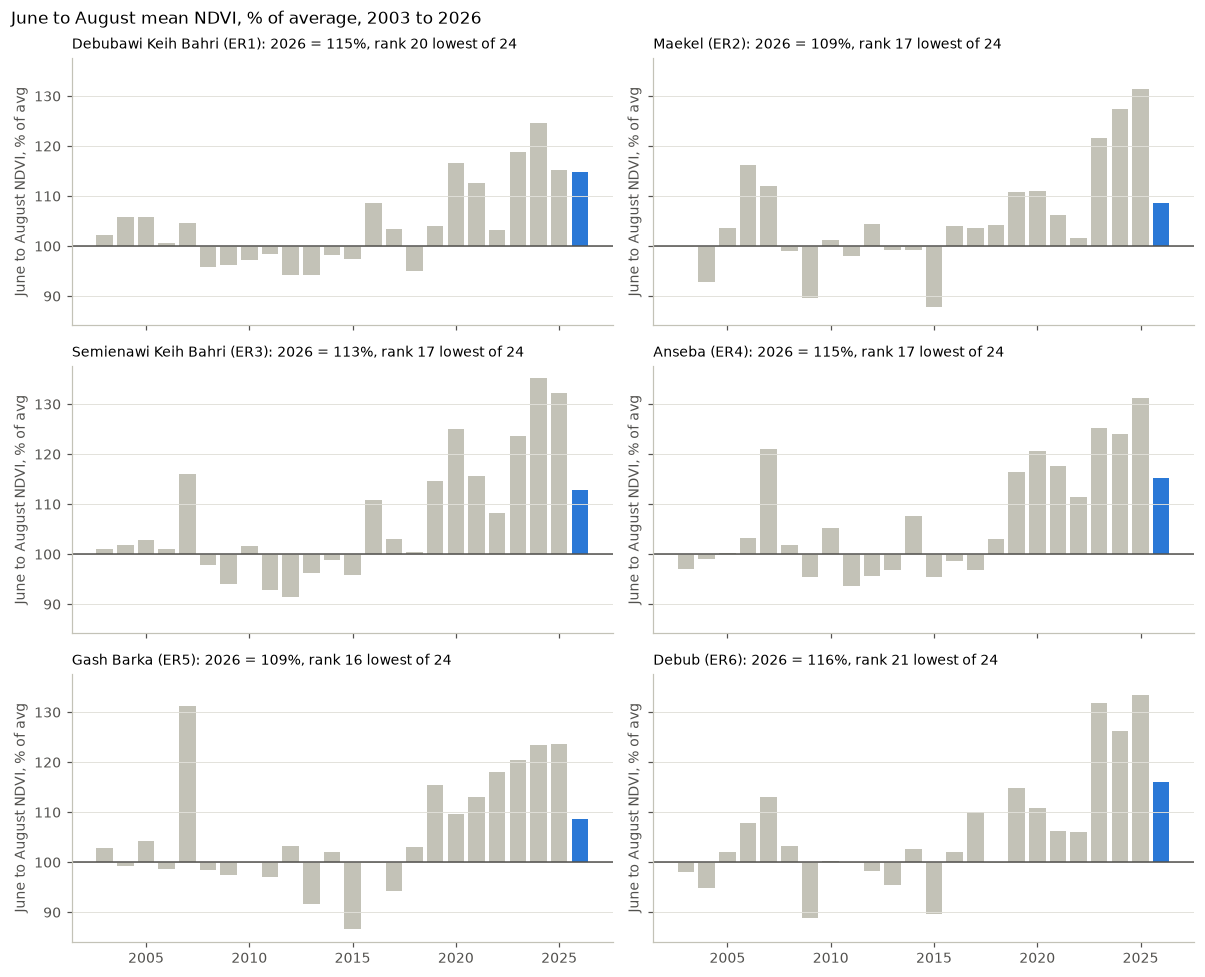

In [7]:
jja_ndvi = (
    ndvi[ndvi.month.isin(JJA) & (ndvi.year >= 2003)]
    .groupby(["PCODE", "year"], as_index=False)
    .agg(viq=("viq", "mean"), n_dekads=("viq", "size"))
)
assert (jja_ndvi.n_dekads == 9).all()
jja_ndvi["rank_lowest"] = jja_ndvi.groupby("PCODE").viq.rank(method="min").astype(int)
n_ndvi = jja_ndvi.year.nunique()

fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, p in zip(axes.flat, ORDER):
    d = jja_ndvi[jja_ndvi.PCODE == p]
    colors = np.where(d.year == CURRENT, C_CURRENT, C_PAST)
    ax.bar(d.year, d.viq - 100, bottom=100, color=colors, width=0.8)
    ax.axhline(100, color=C_AVG, lw=1)
    cur = d[d.year == CURRENT].iloc[0]
    ax.set_title(
        f"{LABEL[p]}: {CURRENT} = {cur.viq:.0f}%, rank {cur.rank_lowest} lowest of {n_ndvi}",
        loc="left",
        fontsize=9,
    )
    ax.set_ylabel("June to August NDVI, % of avg")
fig.suptitle(f"June to August mean NDVI, % of average, 2003 to {CURRENT}", x=0.01, ha="left")
fig.tight_layout()
plt.show()

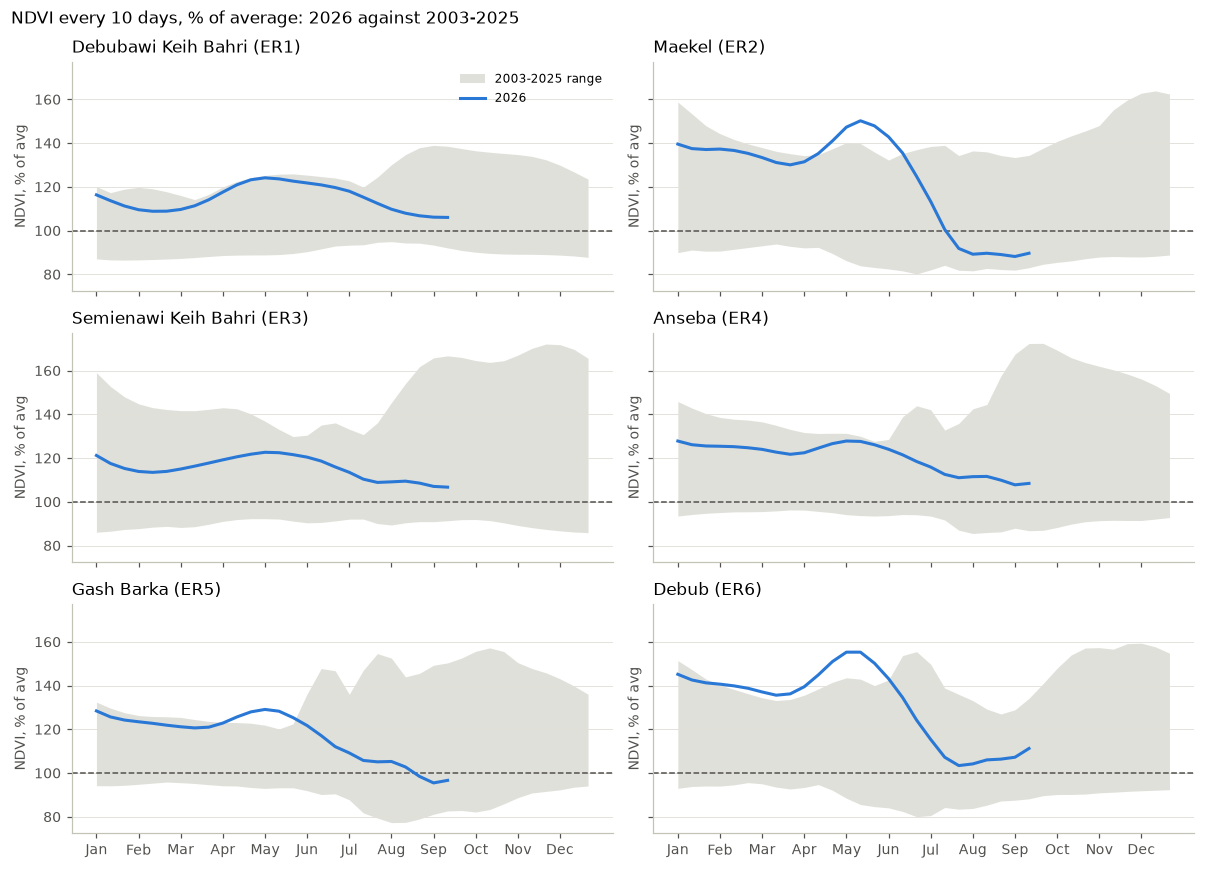

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, p in zip(axes.flat, ORDER):
    d = ndvi[(ndvi.PCODE == p) & (ndvi.year >= 2003)].copy()
    d["dekad"] = d.date.dt.strftime("%m-%d")
    past = d[d.year < CURRENT].groupby("dekad").viq.agg(["min", "max"])
    cur = d[d.year == CURRENT].set_index("dekad").viq
    x = np.arange(len(past))
    ax.fill_between(x, past["min"], past["max"], color=C_PAST, alpha=0.5, lw=0, label="2003-2025 range")
    ax.axhline(100, color=C_AVG, lw=1, ls="--")
    ax.plot(x[: len(cur)], cur.values, color=C_CURRENT, lw=2, label=str(CURRENT))
    month_ticks(ax, past.index)
    ax.set_title(LABEL[p], loc="left")
    ax.set_ylabel("NDVI, % of avg")
axes.flat[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"NDVI every 10 days, % of average: {CURRENT} against 2003-2025", x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [9]:
latest = ndvi.date.max()
ndvi_latest = (
    ndvi[ndvi.date.dt.strftime("%m-%d") == latest.strftime("%m-%d")]
    .assign(rank_lowest=lambda d: d.groupby("PCODE").viq.rank(method="min").astype(int))
    .query("year == @CURRENT")
    .set_index("PCODE")
    .loc[ORDER, ["adm1_name", "viq", "rank_lowest"]]
    .round(0)
)
print(f"NDVI for the dekad starting {latest:%d %b %Y}, rank among {ndvi.year.nunique()} years with that dekad")
ndvi_latest

NDVI for the dekad starting 11 Sep 2026, rank among 25 years with that dekad


,adm1_name,viq,rank_lowest
PCODE,,,
ER1,Debubawi Keih Bahri,106.0,18
ER2,Maekel,90.0,5
ER3,Semienawi Keih Bahri,107.0,16
ER4,Anseba,108.0,16
ER5,Gash Barka,97.0,9
ER6,Debub,111.0,19


## 3. Combined Drought Indicator (ICPAC)

Class values from the EADW CDI factsheet: 1 to 3 Watch (precipitation shortage),
4 to 6 Warning (+ soil moisture anomaly), 7 to 10 Alert (+ vegetation anomaly),
11 to 12 Partial recovery, 13 to 14 Full recovery. Value 0 is not in the
factsheet table and is shown as "no class". Value 15 appears in 2022 and 2023
files and is not in the factsheet table either.

Pixel counts per admin 1 are cached on blob; set `REFRESH = True` to rebuild
from HDX.

In [10]:
CDI_BLOB = f"{PROJECT_PREFIX}/processed/cdi_adm1_jja_counts.parquet"
REFRESH = False
if REFRESH:
    counts = cdi.cdi_adm1(list(range(2020, CURRENT + 1)), JJA, adm1)
    stratus.upload_parquet_to_blob(counts, CDI_BLOB, stage="dev")
else:
    counts = stratus.load_parquet_from_blob(CDI_BLOB, stage="dev")

GROUPS = [
    ("Watch", range(1, 4), DRY[0]),
    ("Warning", range(4, 7), DRY[1]),
    ("Alert", range(7, 11), DRY[2]),
    ("Recovery", range(11, 15), C_PAST),
    ("Value 15 (not in factsheet)", [15], "white"),
]
to_group = {v: g for g, vals, _ in GROUPS for v in vals}
counts["group"] = counts.cdi.map(to_group).fillna("No class")
share = (
    counts.groupby(["PCODE", "year", "month", "group"]).n.sum()
    / counts.groupby(["PCODE", "year", "month"]).n.sum()
    * 100
).rename("pct_area").reset_index()

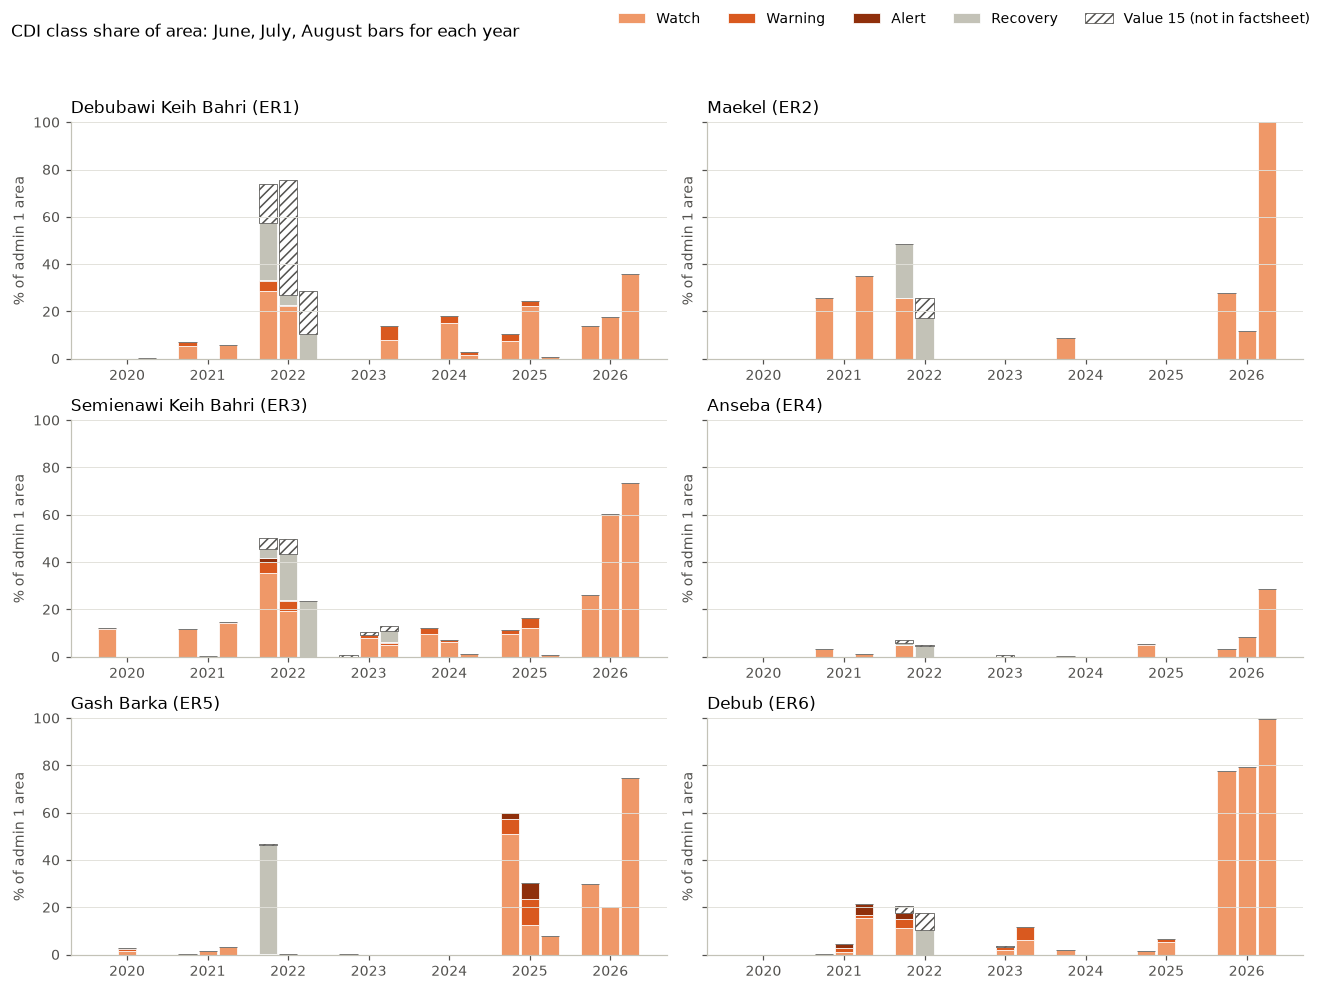

In [11]:
years = sorted(share.year.unique())
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharey=True)
for ax, p in zip(axes.flat, ORDER):
    d = share[share.PCODE == p].pivot_table(
        index=["year", "month"], columns="group", values="pct_area", fill_value=0
    )
    idx = pd.MultiIndex.from_product([years, JJA])
    d = d.reindex(idx, fill_value=0)
    x = np.array([i * 4 + j for i in range(len(years)) for j in range(3)], dtype=float)
    bottom = np.zeros(len(d))
    for g, _, color in GROUPS:
        if g in d:
            hatched = g.startswith("Value 15")
            ax.bar(
                x, d[g], bottom=bottom, color=color, width=0.9, label=g,
                edgecolor=C_AVG if hatched else "white", lw=0.5, hatch="////" if hatched else None,
            )
            bottom += d[g].values
    ax.set_xticks(x[1::3], years)
    ax.set_title(LABEL[p], loc="left")
    ax.set_ylabel("% of admin 1 area")
    ax.set_ylim(0, 100)
handles, labels = axes.flat[0].get_legend_handles_labels()
for a in axes.flat[1:]:
    for h, lab in zip(*a.get_legend_handles_labels()):
        if lab not in labels:
            handles.append(h)
            labels.append(lab)
fig.legend(handles, labels, loc="upper right", ncol=5, frameon=False)
fig.suptitle("CDI class share of area: June, July, August bars for each year", x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

CDI maps for June, July and August 2026, from the Eritrea COGs on blob, masked to
the country border.

C:\Users\pauni\Desktop\Work\OCHA\GitHub\ds-eri-drought\.venv\Lib\site-packages\rioxarray\_io.py:939: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


C:\Users\pauni\Desktop\Work\OCHA\GitHub\ds-eri-drought\.venv\Lib\site-packages\rioxarray\_io.py:939: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


C:\Users\pauni\Desktop\Work\OCHA\GitHub\ds-eri-drought\.venv\Lib\site-packages\rioxarray\_io.py:939: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


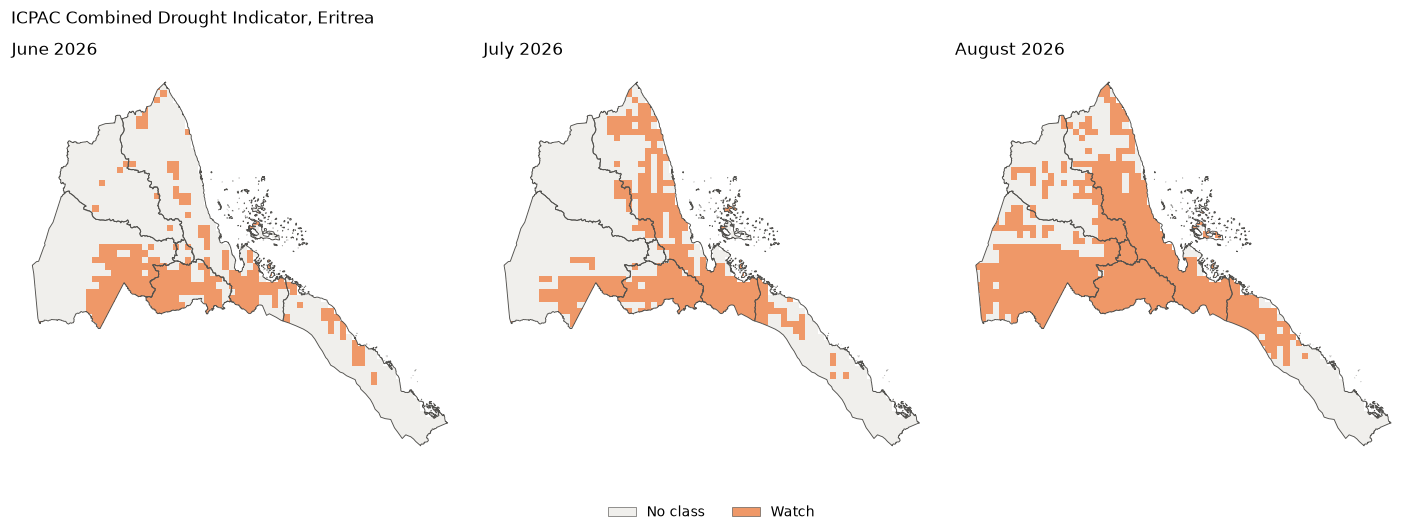

In [12]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

MAP_GROUPS = [("No class", [0], NEUTRAL)] + [
    (g, vals, "#898781" if g.startswith("Value 15") else color) for g, vals, color in GROUPS
]
map_cmap = ListedColormap([c for _, _, c in MAP_GROUPS])
value_to_idx = {v: i for i, (_, vals, _) in enumerate(MAP_GROUPS) for v in vals}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
present = set()
for ax, month in zip(axes, JJA):
    da = stratus.open_blob_cog(cdi.cog_blob_name(CURRENT, month)).squeeze(drop=True)
    da = da.rio.clip(list(adm1.geometry), adm1.crs, drop=True).load()
    vals = da.values
    idx = np.full(vals.shape, np.nan)
    for v, i in value_to_idx.items():
        idx[vals == v] = i
    present |= {int(i) for i in np.unique(idx[~np.isnan(idx)])}
    xs, ys = da.x.values, da.y.values
    ax.imshow(
        idx, cmap=map_cmap, vmin=-0.5, vmax=len(MAP_GROUPS) - 0.5, interpolation="nearest",
        extent=(xs[0], xs[-1], ys[-1], ys[0]),
    )
    adm1.boundary.plot(ax=ax, color=C_AVG, linewidth=0.6)
    ax.set_title(pd.Timestamp(CURRENT, month, 1).strftime("%B %Y"), loc="left")
    ax.set_axis_off()
fig.legend(
    [Patch(facecolor=MAP_GROUPS[i][2], edgecolor=C_AVG, lw=0.4) for i in sorted(present)],
    [MAP_GROUPS[i][0] for i in sorted(present)],
    loc="lower center", ncol=len(present), frameon=False,
)
fig.suptitle("ICPAC Combined Drought Indicator, Eritrea", x=0.01, ha="left")
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()

In [13]:
cdi_cols = [g for g, _, _ in GROUPS]
cdi_tbl = (
    share.pivot_table(
        index=["PCODE", "year", "month"], columns="group", values="pct_area", fill_value=0
    )
    .reindex(columns=cdi_cols, fill_value=0)
    .groupby(["PCODE", "year"])
    .mean()
    .round(0)
)
cdi_tbl["watch_warning_alert"] = cdi_tbl.reindex(
    columns=["Watch", "Warning", "Alert"], fill_value=0
).sum(axis=1)
print("Mean share of area over Jun, Jul, Aug (%)")
cdi_tbl

Mean share of area over Jun, Jul, Aug (%)


group       Watch  Warning  Alert  Recovery  Value 15 (not in factsheet)  \
PCODE year                                                                 
ER1   2020    0.0      0.0    0.0       0.0                          0.0   
      2021    4.0      1.0    0.0       0.0                          0.0   
      2022   17.0      1.0    0.0      13.0                         28.0   
      2023    3.0      2.0    0.0       0.0                          0.0   
      2024    6.0      1.0    0.0       0.0                          0.0   
      2025   10.0      2.0    0.0       0.0                          0.0   
      2026   22.0      0.0    0.0       0.0                          0.0   
ER2   2020    0.0      0.0    0.0       0.0                          0.0   
      2021   20.0      0.0    0.0       0.0                          0.0   
      2022    9.0      0.0    0.0      13.0                          3.0   
      2023    0.0      0.0    0.0       0.0                          0.0   
      2024    3.0      0.0    0.0       0.0                          0.0   
      2025    0.0      0.0    0.0       0.0                          0.0   
      2026   46.0      0.0    0.0       0.0                          0.0   
ER3   2020    4.0      0.0    0.0       0.0                          0.0   
      2021    9.0      0.0    0.0       0.0                          0.0   
      2022   18.0      3.0    1.0      16.0                          4.0   
      2023    4.0      1.0    0.0       2.0                          1.0   
      2024    6.0      1.0    0.0       0.0                          0.0   
      2025    7.0      2.0    0.0       0.0                          0.0   
      2026   53.0      0.0    0.0       0.0                          0.0   
ER4   2020    0.0      0.0    0.0       0.0                          0.0   
      2021    1.0      0.0    0.0       0.0                          0.0   
      2022    2.0      0.0    0.0       2.0                          1.0   
      2023    0.0      0.0    0.0       0.0                          0.0   
      2024    0.0      0.0    0.0       0.0                          0.0   
      2025    2.0      0.0    0.0       0.0                          0.0   
      2026   13.0      0.0    0.0       0.0                          0.0   
ER5   2020    0.0      0.0    0.0       0.0                          0.0   
      2021    2.0      0.0    0.0       0.0                          0.0   
      2022    0.0      0.0    0.0      16.0                          0.0   
      2023    0.0      0.0    0.0       0.0                          0.0   
      2024    0.0      0.0    0.0       0.0                          0.0   
      2025   24.0      6.0    3.0       0.0                          0.0   
      2026   42.0      0.0    0.0       0.0                          0.0   
ER6   2020    0.0      0.0    0.0       0.0                          0.0   
      2021    6.0      1.0    2.0       0.0                          0.0   
      2022    4.0      1.0    1.0       3.0                          3.0   
      2023    3.0      2.0    0.0       0.0                          0.0   
      2024    1.0      0.0    0.0       0.0                          0.0   
      2025    2.0      0.0    0.0       0.0                          0.0   
      2026   85.0      0.0    0.0       0.0                          0.0   

group       watch_warning_alert  
PCODE year                       
ER1   2020                  0.0  
      2021                  5.0  
      2022                 18.0  
      2023                  5.0  
      2024                  7.0  
      2025                 12.0  
      2026                 22.0  
ER2   2020                  0.0  
      2021                 20.0  
      2022                  9.0  
      2023                  0.0  
      2024                  3.0  
      2025                  0.0  
      2026                 46.0  
ER3   2020                  4.0  
      2021                  9.0  
      2022                 22.0  
      202